# Load Parsed Table

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Works when the notebook starts in the root or notebooks folder.
ROOT = Path.cwd()

if not (ROOT / "requirements.txt").exists():
    ROOT = ROOT.parent

if not (ROOT / "requirements.txt").exists():
    raise RuntimeError("Open the notebook from the project folder.")

reads = pd.read_parquet(ROOT / "data/processed/data2_reads.parquet")

SITE_KEYS = ["transcript_id", "transcript_position"]

display(reads.head())
print(f"Read rows: {len(reads):,}")

,transcript_id,transcript_position,sequence,central_5mer,n_reads,read_idx,minus1_dwell,minus1_signal_sd,minus1_signal_mean,central_dwell,central_signal_sd,central_signal_mean,plus1_dwell,plus1_signal_sd,plus1_signal_mean,gene_id,label
0,tx_id_0,0,AAAACCT,AAACC,885,0,0.01220,3.99,106.0,0.00337,4.56,102.0,0.00664,4.20,84.2,NaN,1.0
1,tx_id_0,0,AAAACCT,AAACC,885,1,0.03020,2.32,107.0,0.00443,2.36,102.0,0.00332,2.13,79.2,NaN,1.0
2,tx_id_0,0,AAAACCT,AAACC,885,2,0.00232,5.55,110.0,0.00664,7.04,99.3,0.00232,2.21,86.6,NaN,1.0
3,tx_id_0,0,AAAACCT,AAACC,885,3,0.00465,2.10,104.0,0.00996,3.90,108.0,0.00401,2.18,82.2,NaN,1.0
4,tx_id_0,0,AAAACCT,AAACC,885,4,0.02110,3.49,103.0,0.00531,3.80,101.0,0.00997,2.18,81.2,NaN,1.0


Read rows: 1,171,940


# Site Table
For EDA.

In [2]:
# Validate the repeated site metadata before creating site table
site_metadata = [
    "sequence",
    "central_5mer",
    "n_reads",
    "gene_id",
    "label",
]

metadata_counts = (
    reads.groupby(SITE_KEYS)[site_metadata]
    .nunique(dropna=False)
)

assert not metadata_counts.gt(1).any().any(), (
    "Some sites have inconsistent metadata."
)

assert not reads.duplicated(
    SITE_KEYS + ["read_idx"]
).any(), "Duplicate read keys found."

assert reads["central_5mer"].eq(
    reads["sequence"].str[1:6]
).all(), "Central 5-mer does not match the sequence."

# Check that the stored count matches the actual number of rows.
coverage_check = (
    reads.groupby(SITE_KEYS)
    .agg(
        observed_reads=("read_idx", "size"),
        stored_n_reads=("n_reads", "first"),
    )
)

assert coverage_check["observed_reads"].eq(
    coverage_check["stored_n_reads"]
).all(), "Stored n_reads does not match the parsed rows."

print("Site metadata and read counts are consistent.")

Site metadata and read counts are consistent.


In [3]:
# One row per site for site-level counts.
sites = (
    reads[SITE_KEYS + site_metadata]
    .drop_duplicates(subset=SITE_KEYS)
    .reset_index(drop=True)
    .copy()
)

# All sites for coverage and data-quality analysis are kept.
# Only labelled records for label comparisons are used.
labelled_sites = sites.dropna(subset=["label"]).copy()
labelled_reads = reads.dropna(subset=["label"]).copy()

summary = pd.Series({
    "read_rows": len(reads),
    "sites": len(sites),
    "transcripts": sites["transcript_id"].nunique(),
    "genes_with_metadata": sites["gene_id"].nunique(),
    "sites_without_labels": sites["label"].isna().sum(),
})

display(summary)
display(sites.head())

read_rows               1171940
sites                      1323
transcripts                   7
genes_with_metadata           0
sites_without_labels          0
dtype: int64

,transcript_id,transcript_position,sequence,central_5mer,n_reads,gene_id,label
0,tx_id_0,0,AAAACCT,AAACC,885,NaN,1.0
1,tx_id_0,10,TGGACCC,GGACC,1069,NaN,1.0
2,tx_id_0,20,GGGACTA,GGACT,1933,NaN,1.0
3,tx_id_0,30,TGGACCA,GGACC,678,NaN,1.0
4,tx_id_0,40,TAGACTA,AGACT,1868,NaN,1.0


# EDA

## Dataset Summary

In [5]:
summary = pd.Series({
    "site_read_observations": len(reads),
    "sites": len(sites),
    "transcripts": sites["transcript_id"].nunique(),
    "genes_with_metadata": sites["gene_id"].nunique(),
    "sites_without_labels": int(sites["label"].isna().sum()),
    "read_rows_without_labels": int(reads["label"].isna().sum()),
})

display(summary)

# Missing values in each column of the per-read table.
display(
    reads.isna().sum()
    .sort_values(ascending=False)
)

site_read_observations      1171940
sites                          1323
transcripts                       7
genes_with_metadata               0
sites_without_labels              0
read_rows_without_labels          0
dtype: int64

gene_id                 1171940
transcript_id                 0
transcript_position           0
sequence                      0
n_reads                       0
central_5mer                  0
minus1_dwell                  0
minus1_signal_sd              0
minus1_signal_mean            0
read_idx                      0
central_dwell                 0
central_signal_sd             0
plus1_dwell                   0
central_signal_mean           0
plus1_signal_sd               0
plus1_signal_mean             0
label                         0
provided_label_value          0
dtype: int64

## Label Distribution

count    1323.000000
mean        0.592857
std         0.339696
min         0.000000
25%         0.250000
50%         0.700000
75%         0.950000
max         1.000000
Name: label, dtype: float64

,sites,percentage_of_nonmissing_sites
label,,
0.00,189,14.285714
0.25,189,14.285714
0.50,189,14.285714
0.70,189,14.285714
0.75,189,14.285714
0.95,189,14.285714
1.00,189,14.285714


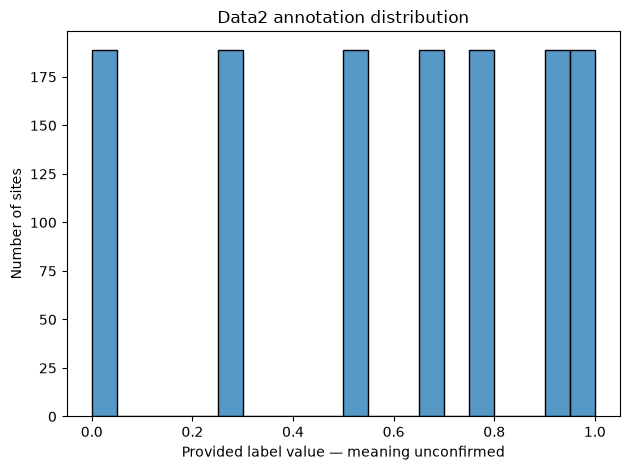

In [ ]:
info2 = pd.read_csv(
    ROOT / "data/raw/data2/data.info",
    dtype={"transcript_id": "string"},
)

values = info2["label"].dropna()

display(values.describe())

value_counts = values.value_counts().sort_index()

display(
    pd.DataFrame({
        "sites": value_counts,
        "percentage_of_nonmissing_sites": (
            100 * value_counts / value_counts.sum()
        ),
    })
)

sns.histplot(values, bins=20, binrange=(0, 1))
plt.xlabel("Provided label value — meaning unconfirmed")
plt.ylabel("Number of sites")
plt.title("Data2 annotation distribution")
plt.tight_layout()
plt.show()

In [9]:
per_transcript = (
    info2.groupby("transcript_id")
    .agg(
        n_sites=("transcript_position", "size"),
        n_distinct_values=("label", "nunique"),
        n_missing_values=(
            "label",
            lambda x: x.isna().sum(),
        ),
    )
)

display(per_transcript.head(10))

# Single-site transcripts cannot demonstrate consistency across sites.
eligible = per_transcript.loc[
    (per_transcript["n_sites"] > 1)
    & (per_transcript["n_missing_values"] == 0)
]

if not eligible.empty:
    constant_fraction = eligible["n_distinct_values"].eq(1).mean()

    print(
        "Among complete multi-site transcripts, percentage with "
        f"one shared annotation value: {100 * constant_fraction:.1f}%"
    )

,n_sites,n_distinct_values,n_missing_values
transcript_id,,,
tx_id_0,189,1,0
tx_id_1,189,1,0
tx_id_2,189,1,0
tx_id_3,189,1,0
tx_id_4,189,1,0
tx_id_5,189,1,0
tx_id_6,189,1,0


Among complete multi-site transcripts, percentage with one shared annotation value: 100.0%


## Read coverage
Sites with few reads may have less stable summary statistics.

count    1323.000000
mean      885.820106
std       564.544252
min        26.000000
1%         50.000000
5%        112.000000
25%       440.000000
50%       814.000000
75%      1269.500000
95%      1868.000000
99%      2395.120000
max      3438.000000
Name: n_reads, dtype: float64

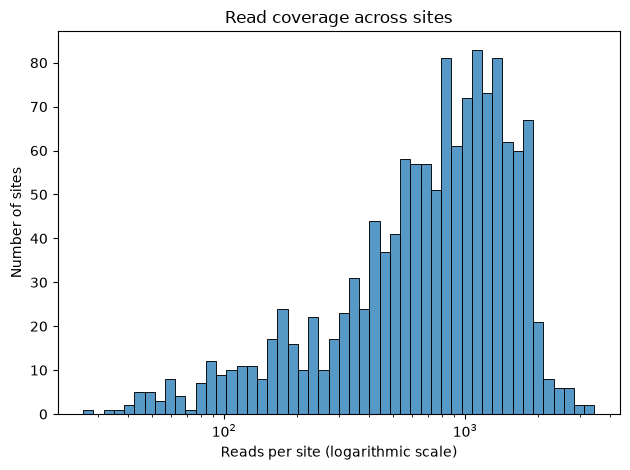

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0.00,189.0,1233.507937,384.539689,329.0,956.0,1205.0,1505.0,1958.0
0.25,189.0,779.941799,525.785139,32.0,352.0,672.0,1122.0,2488.0
0.50,189.0,992.539683,762.774321,44.0,352.0,850.0,1388.0,3438.0
0.70,189.0,750.455026,505.958343,47.0,361.0,640.0,1046.0,2056.0
0.75,189.0,728.920635,549.593747,45.0,324.0,589.0,980.0,2340.0
0.95,189.0,614.708995,400.274035,26.0,324.0,550.0,802.0,1900.0
1.00,189.0,1100.666667,457.182177,58.0,752.0,1124.0,1429.0,1952.0


In [9]:
display(
    sites["n_reads"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

sns.histplot(
    data=sites,
    x="n_reads",
    bins=50,
    log_scale=True,
)

plt.xlabel("Reads per site (logarithmic scale)")
plt.ylabel("Number of sites")
plt.title("Read coverage across sites")
plt.tight_layout()
plt.show()

display(
    labelled_sites.groupby("label")["n_reads"].describe()
)

In [10]:
# Descriptive cutoffs for EDA, not filtering rules.
coverage_summary = pd.DataFrame([
    {
        "condition": f"n_reads < {cutoff}",
        "sites": int((sites["n_reads"] < cutoff).sum()),
        "percentage": 100 * (sites["n_reads"] < cutoff).mean(),
    }
    for cutoff in [5, 10, 20]
])

display(coverage_summary)

,condition,sites,percentage
0,n_reads < 5,0,0.0
1,n_reads < 10,0,0.0
2,n_reads < 20,0,0.0


## Sites per transcript

In [11]:
sites_per_transcript = (
    info2.groupby("transcript_id")
    .size()
    .rename("n_sites")
    .sort_values(ascending=False)
)

display(sites_per_transcript.to_frame())
display(sites_per_transcript.describe())

# Show whether transcript sizes are identical across the whole dataset.
size_counts = (
    sites_per_transcript.value_counts()
    .sort_index()
)

display(
    size_counts.rename_axis("sites_per_transcript")
    .rename("number_of_transcripts")
    .to_frame()
)

,n_sites
transcript_id,
tx_id_0,189
tx_id_1,189
tx_id_2,189
tx_id_3,189
tx_id_4,189
tx_id_5,189
tx_id_6,189


count      7.0
mean     189.0
std        0.0
min      189.0
25%      189.0
50%      189.0
75%      189.0
max      189.0
Name: n_sites, dtype: float64

,number_of_transcripts
sites_per_transcript,
189,7


In [12]:
signal_sites2 = sites[SITE_KEYS + ["sequence", "central_5mer", "n_reads"]].copy()
sites2 = sites.copy()
print(f"Number of signal sites: {len(signal_sites2):,}")
display(sites2.head())

Number of signal sites: 1,323


,transcript_id,transcript_position,sequence,central_5mer,n_reads,gene_id,label,provided_label_value
0,tx_id_0,0,AAAACCT,AAACC,885,NaN,1.0,1.0
1,tx_id_0,10,TGGACCC,GGACC,1069,NaN,1.0,1.0
2,tx_id_0,20,GGGACTA,GGACT,1933,NaN,1.0,1.0
3,tx_id_0,30,TGGACCA,GGACC,678,NaN,1.0,1.0
4,tx_id_0,40,TAGACTA,AGACT,1868,NaN,1.0,1.0


## Full 7-mer and central 5-mer frequencies

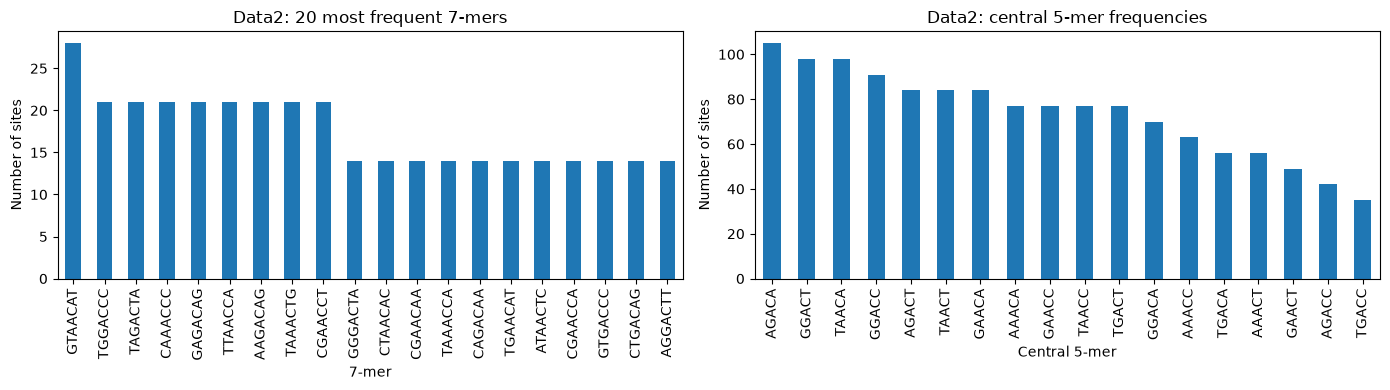

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sites2["sequence"].value_counts().head(20).plot.bar(
    ax=axes[0]
)
axes[0].set_title("Data2: 20 most frequent 7-mers")
axes[0].set_xlabel("7-mer")
axes[0].set_ylabel("Number of sites")

sites2["central_5mer"].value_counts().plot.bar(
    ax=axes[1]
)
axes[1].set_title("Data2: central 5-mer frequencies")
axes[1].set_xlabel("Central 5-mer")
axes[1].set_ylabel("Number of sites")

plt.tight_layout()
plt.show()

## Compare freq across annotation values
Percentages are calculated within each provided-value group. Because annotations are constant within transcripts, differences between groups may also reflect transcript differences. These are descriptive comparisons, not evidence that the values are confirmed modification probabilities.

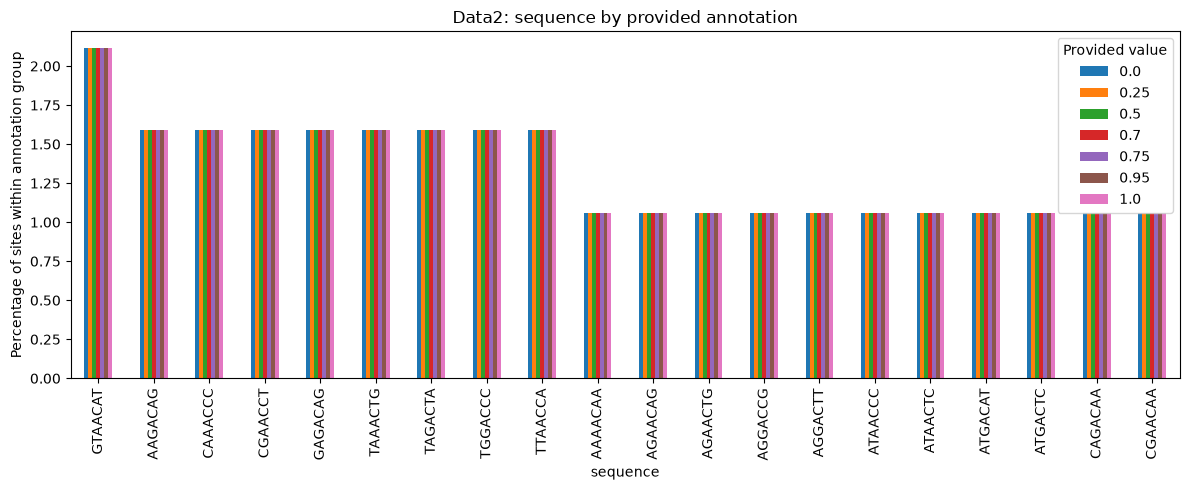

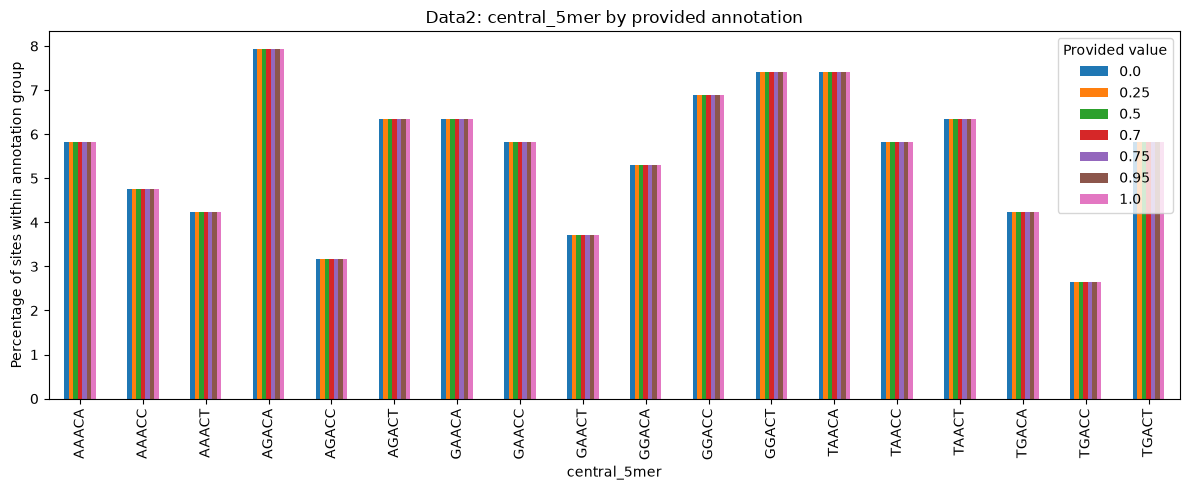

In [ ]:
def plot_sequence_by_annotation(sites, sequence_column, top_n=None):
    usable = sites.dropna(subset=["label"])

    counts = pd.crosstab(
        usable[sequence_column],
        usable["label"],
    )

    if counts.empty:
        raise ValueError("No annotated sites available.")

    if counts.shape[1] > 10:
        raise ValueError(
            "Too many annotation values for a readable grouped plot. "
            "Use overall frequencies for now."
        )

    # Normalise within each annotation group.
    percentages = counts.div(counts.sum(axis=0), axis="columns") * 100

    if top_n is not None:
        top = counts.sum(axis=1).nlargest(top_n).index
        percentages = percentages.loc[top]

    percentages.plot.bar(figsize=(12, 5))
    plt.xlabel(sequence_column)
    plt.ylabel("Percentage of sites within annotation group")
    plt.title(f"Data2: {sequence_column} by provided annotation")
    plt.legend(title="Provided value")
    plt.tight_layout()
    plt.show()


plot_sequence_by_annotation(sites2, "sequence", top_n=20)
plot_sequence_by_annotation(sites2, "central_5mer")

## Sequence motifs


label,unmodified_sites,modified_sites,total_sites,positive_fraction
central_5mer,,,,
AGACA,15,15,30,0.5
GGACT,14,14,28,0.5
TAACA,14,14,28,0.5
GGACC,13,13,26,0.5
TAACT,12,12,24,0.5
AGACT,12,12,24,0.5
GAACA,12,12,24,0.5
AAACA,11,11,22,0.5
TAACC,11,11,22,0.5


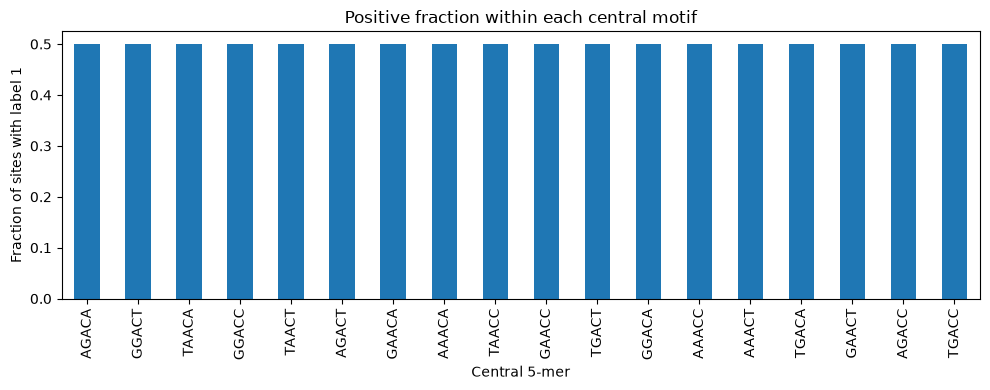

In [15]:
motif_counts = pd.crosstab(
    labelled_sites["central_5mer"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

motif_summary = motif_counts.rename(
    columns={0: "unmodified_sites", 1: "modified_sites"}
)

motif_summary["total_sites"] = motif_summary.sum(axis=1)

motif_summary["positive_fraction"] = (
    motif_summary["modified_sites"]
    / motif_summary["total_sites"]
)

motif_summary = motif_summary.sort_values(
    "total_sites", ascending=False
)

display(motif_summary)

motif_summary["positive_fraction"].plot.bar(
    figsize=(10, 4)
)

plt.xlabel("Central 5-mer")
plt.ylabel("Fraction of sites with label 1")
plt.title("Positive fraction within each central motif")
plt.tight_layout()
plt.show()

In [16]:
# Data-quality check to investigate unexpected motifs before deciding whether to exclude anything  
valid_motif = sites["central_5mer"].str.fullmatch(
    r"[AGT][AG]AC[ACT]",
    na=False,
)

print("Sites outside the expected DRACH motif:", (~valid_motif).sum())

display(
    sites.loc[
        ~valid_motif,
        SITE_KEYS + ["sequence", "central_5mer"]
    ].head()
)

Sites outside the expected DRACH motif: 0


,transcript_id,transcript_position,sequence,central_5mer


## Central signal features
Use all annotated read rows, with each decimal annotation value shown as a group. Density curves are normalised separately to compare shapes. High-coverage sites contribute more reads; the annotation is attached to the site, not measured independently for each read.

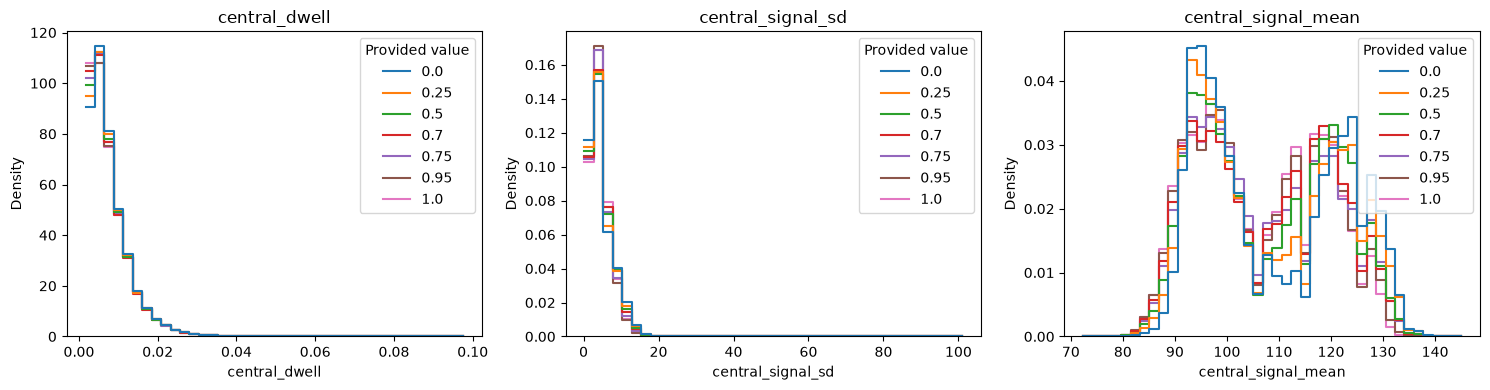

In [18]:
central_features = [
    "central_dwell",
    "central_signal_sd",
    "central_signal_mean",
]

# Treat distinct numeric values as plot groups without altering the annotation.
annotation_order = sorted(labelled_reads["label"].unique())
labelled_reads["annotation_group"] = pd.Categorical(
    labelled_reads["label"],
    categories=annotation_order,
    ordered=True,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature in zip(axes, central_features):
    sns.histplot(
        data=labelled_reads,
        x=feature,
        hue="annotation_group",
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_title(feature)
    if ax.get_legend() is not None:
        ax.get_legend().set_title("Provided value")

plt.tight_layout()
plt.show()

## Compare site averages
Average over all reads at each site, then attach the original annotation. Each site receives equal weight; sites within the same transcript may still be related. This is exploratory aggregation, separate from the production feature-engineering function.

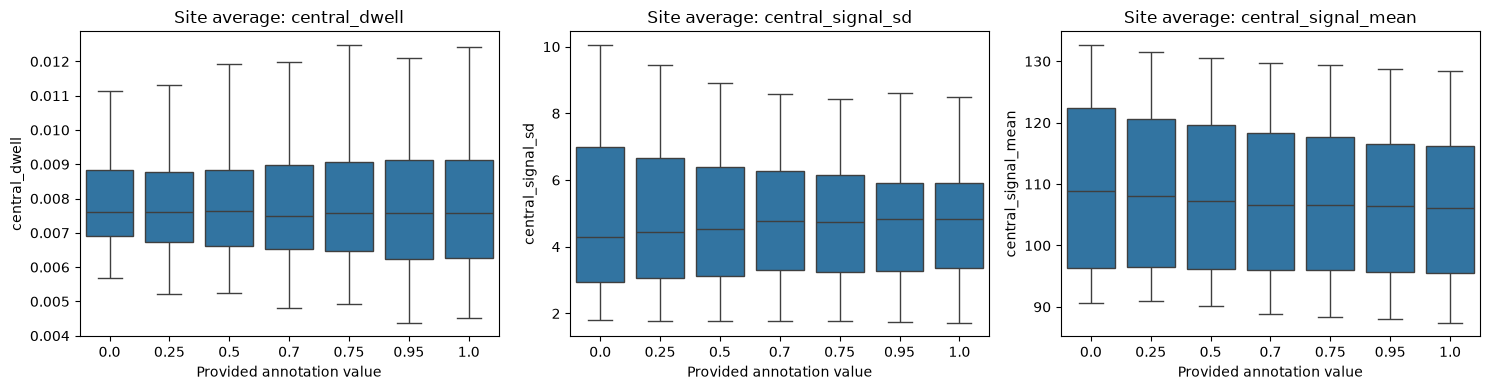

In [19]:
site_means2 = (
    reads
    .groupby(SITE_KEYS, as_index=False)[central_features]
    .mean()
    .merge(
        info2[SITE_KEYS + ["label"]],
        on=SITE_KEYS,
        how="left",
        validate="one_to_one",
    )
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, central_features):
    sns.boxplot(
        data=site_means2,
        x="label",
        y=feature,
        showfliers=False,
        ax=ax,
    )
    ax.set_xlabel("Provided annotation value")
    ax.set_title(f"Site average: {feature}")

plt.tight_layout()
plt.show()